In [302]:
from sklearn.linear_model import LinearRegression
from bokeh.models import HoverTool 
from bokeh.io import export_svg
import numpy as np
import transforms3d as td
import pandas as pd
import bokeh.io
import bokeh.plotting
# Import libraries
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import re
import panel as pn
from bokeh.models import ColumnDataSource
color = bokeh.palettes.d3['Category10'][10]
from bokeh.palettes import Viridis
pn.extension()
import plotly.graph_objects as go
from bokeh.io import export_png
import holoviews as hv
from bokeh.models import CategoricalColorMapper, Legend
from bokeh.layouts import column, row
from bokeh.models import LinearAxis, Range1d
from parse_patient_data import PatientData
import plotly.express as px
import plotly.express as px
bokeh.io.output_notebook()

Loading BokehJS ...

In [304]:
class PatientData(object):
    def __init__(self, filename):
        self.filename = filename
        
        self.file_to_df()
        
        self.max_emg = self.df[['emg%i'%i for i in range(8)]].values.max()
        
    def file_to_df(self):

        df = pd.read_csv(self.filename, low_memory=False, index_col=0)
        
        # Remove NaN rows from dataframe
        df = df[~df['motor_position'].isnull()]
        df = df[~df['futek'].isnull()]
        df.reset_index(inplace = True, drop = True)

        # Convert motor_position to mm
        df['motor_position'] = df['motor_position'] * 0.007 # encoder to mm
        
        df['time_elapsed'] = df['time_elapsed'] - df.loc[0, 'time_elapsed']
        # define df attribute
        self.df = df

    def plot_futek_time(self):
        hover = HoverTool(tooltips=[("index", "$index"),])
        
        p = bokeh.plotting.figure(
                        width=1200,
                        height=600,
                        x_axis_label="time (s)",
                        y_axis_label="Force (Newtons)",
                        #title = '',
                        #x_range = [-45, 110],
                        y_range = [-1, 15],
                        tools = [hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset']
                    )
        p.extra_y_ranges = {"emg": Range1d(start=0, end=self.max_emg + 50)}
        p.add_layout(LinearAxis(y_range_name="emg", axis_label='Myo EMG Amplitude (a.u.)'), 'right')
        # Keep legend outside of plot
        p.add_layout(Legend(), 'right')

        p.line(x = p3.df['time_elapsed'], y = self.df['futek'], color = color[0], line_width = 5, legend_label = 'force')

        for i in range(8):
            p.line(x = p3.df['time_elapsed'], y = self.df['emg%i'%i], color = color[i], line_alpha = 0.7, legend_label = 'emg', y_range_name='emg')

        p.legend.click_policy='hide'
        
        return p
    
    def plot_futek_displacement(self):
        fig = px.scatter_3d(p3.df, x='motor_position', y='time_elapsed', z='futek', color = 'time_elapsed', width=800, height=800)
        return fig

# Load in data file

In [321]:
file = '/Users/kate/Downloads/p3_vibration_data/p3_001.csv'

p3 = PatientData(file)
p3.df

,gt,time_elapsed,current_time,current_task,futek,motor_position,emg0,emg1,emg2,emg3,emg4,emg5,emg6,emg7
0,0,0.000000,20240917135203931,NaN,0.0,0.000,22,31,31,23,24,27,28,27
1,0,0.010099,20240917135203941,NaN,0.0,0.000,22,31,31,23,24,27,28,27
2,0,0.020063,20240917135203951,NaN,0.0,0.000,23,29,30,23,23,27,30,27
3,0,0.030095,20240917135203961,NaN,0.0,0.000,23,29,30,23,23,27,30,27
4,0,0.039903,20240917135203971,NaN,0.0,0.000,22,29,30,24,23,23,30,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6364,0,63.640027,20240917135307571,NaN,0.0,0.112,25,28,32,25,27,36,43,65
6365,0,63.650008,20240917135307581,NaN,0.0,0.112,25,28,32,25,27,36,43,65
6366,0,63.660094,20240917135307591,NaN,0.0,0.112,26,29,31,26,27,36,40,64
6367,0,63.670079,20240917135307601,NaN,0.0,0.112,26,29,31,26,27,36,40,64


# Visualize Force vs. Time

In [314]:
p = p3.plot_futek_time()
bokeh.io.show(p)

# Visualize Force vs. Motor position vs. Time

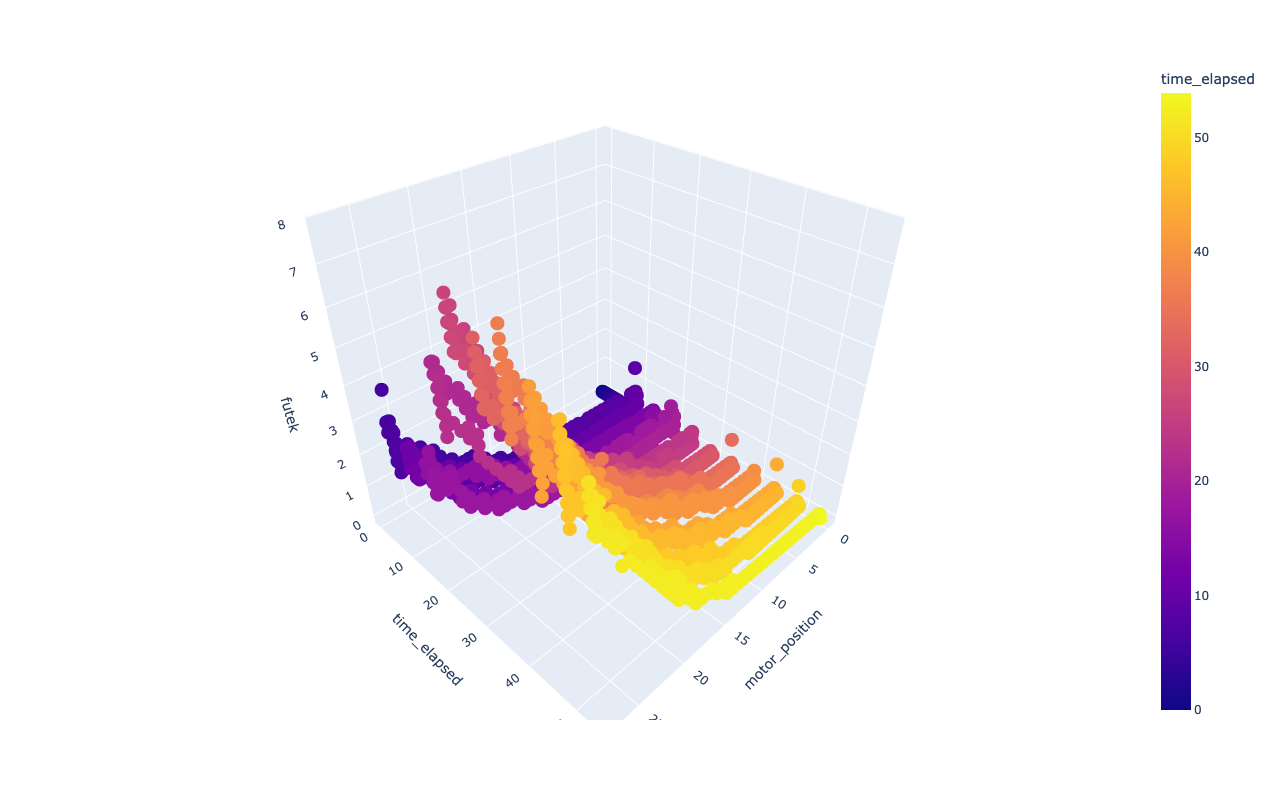

In [310]:
fig = p3.plot_futek_displacement()
fig.show()